In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Lets try this color palette for today eda 
sns.set_palette("Set2")

Data: https://www.kaggle.com/datasets/nvarisha/global-cybersecurity-threats-20152024

In [3]:
path = r"C:\Users\Rudra\Desktop\kaggle\thred-global-ai\Global_Cybersecurity_Threats_2015-2024.csv"

In [4]:
df = pd.read_csv(path)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [6]:
df.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [7]:
for col in df.columns:
    print(f"{col} -> {df[col].nunique()}")

Country -> 10
Year -> 10
Attack Type -> 6
Target Industry -> 7
Financial Loss (in Million $) -> 2536
Number of Affected Users -> 2998
Attack Source -> 4
Security Vulnerability Type -> 4
Defense Mechanism Used -> 5
Incident Resolution Time (in Hours) -> 72


In [8]:
countries = df["Country"].unique()

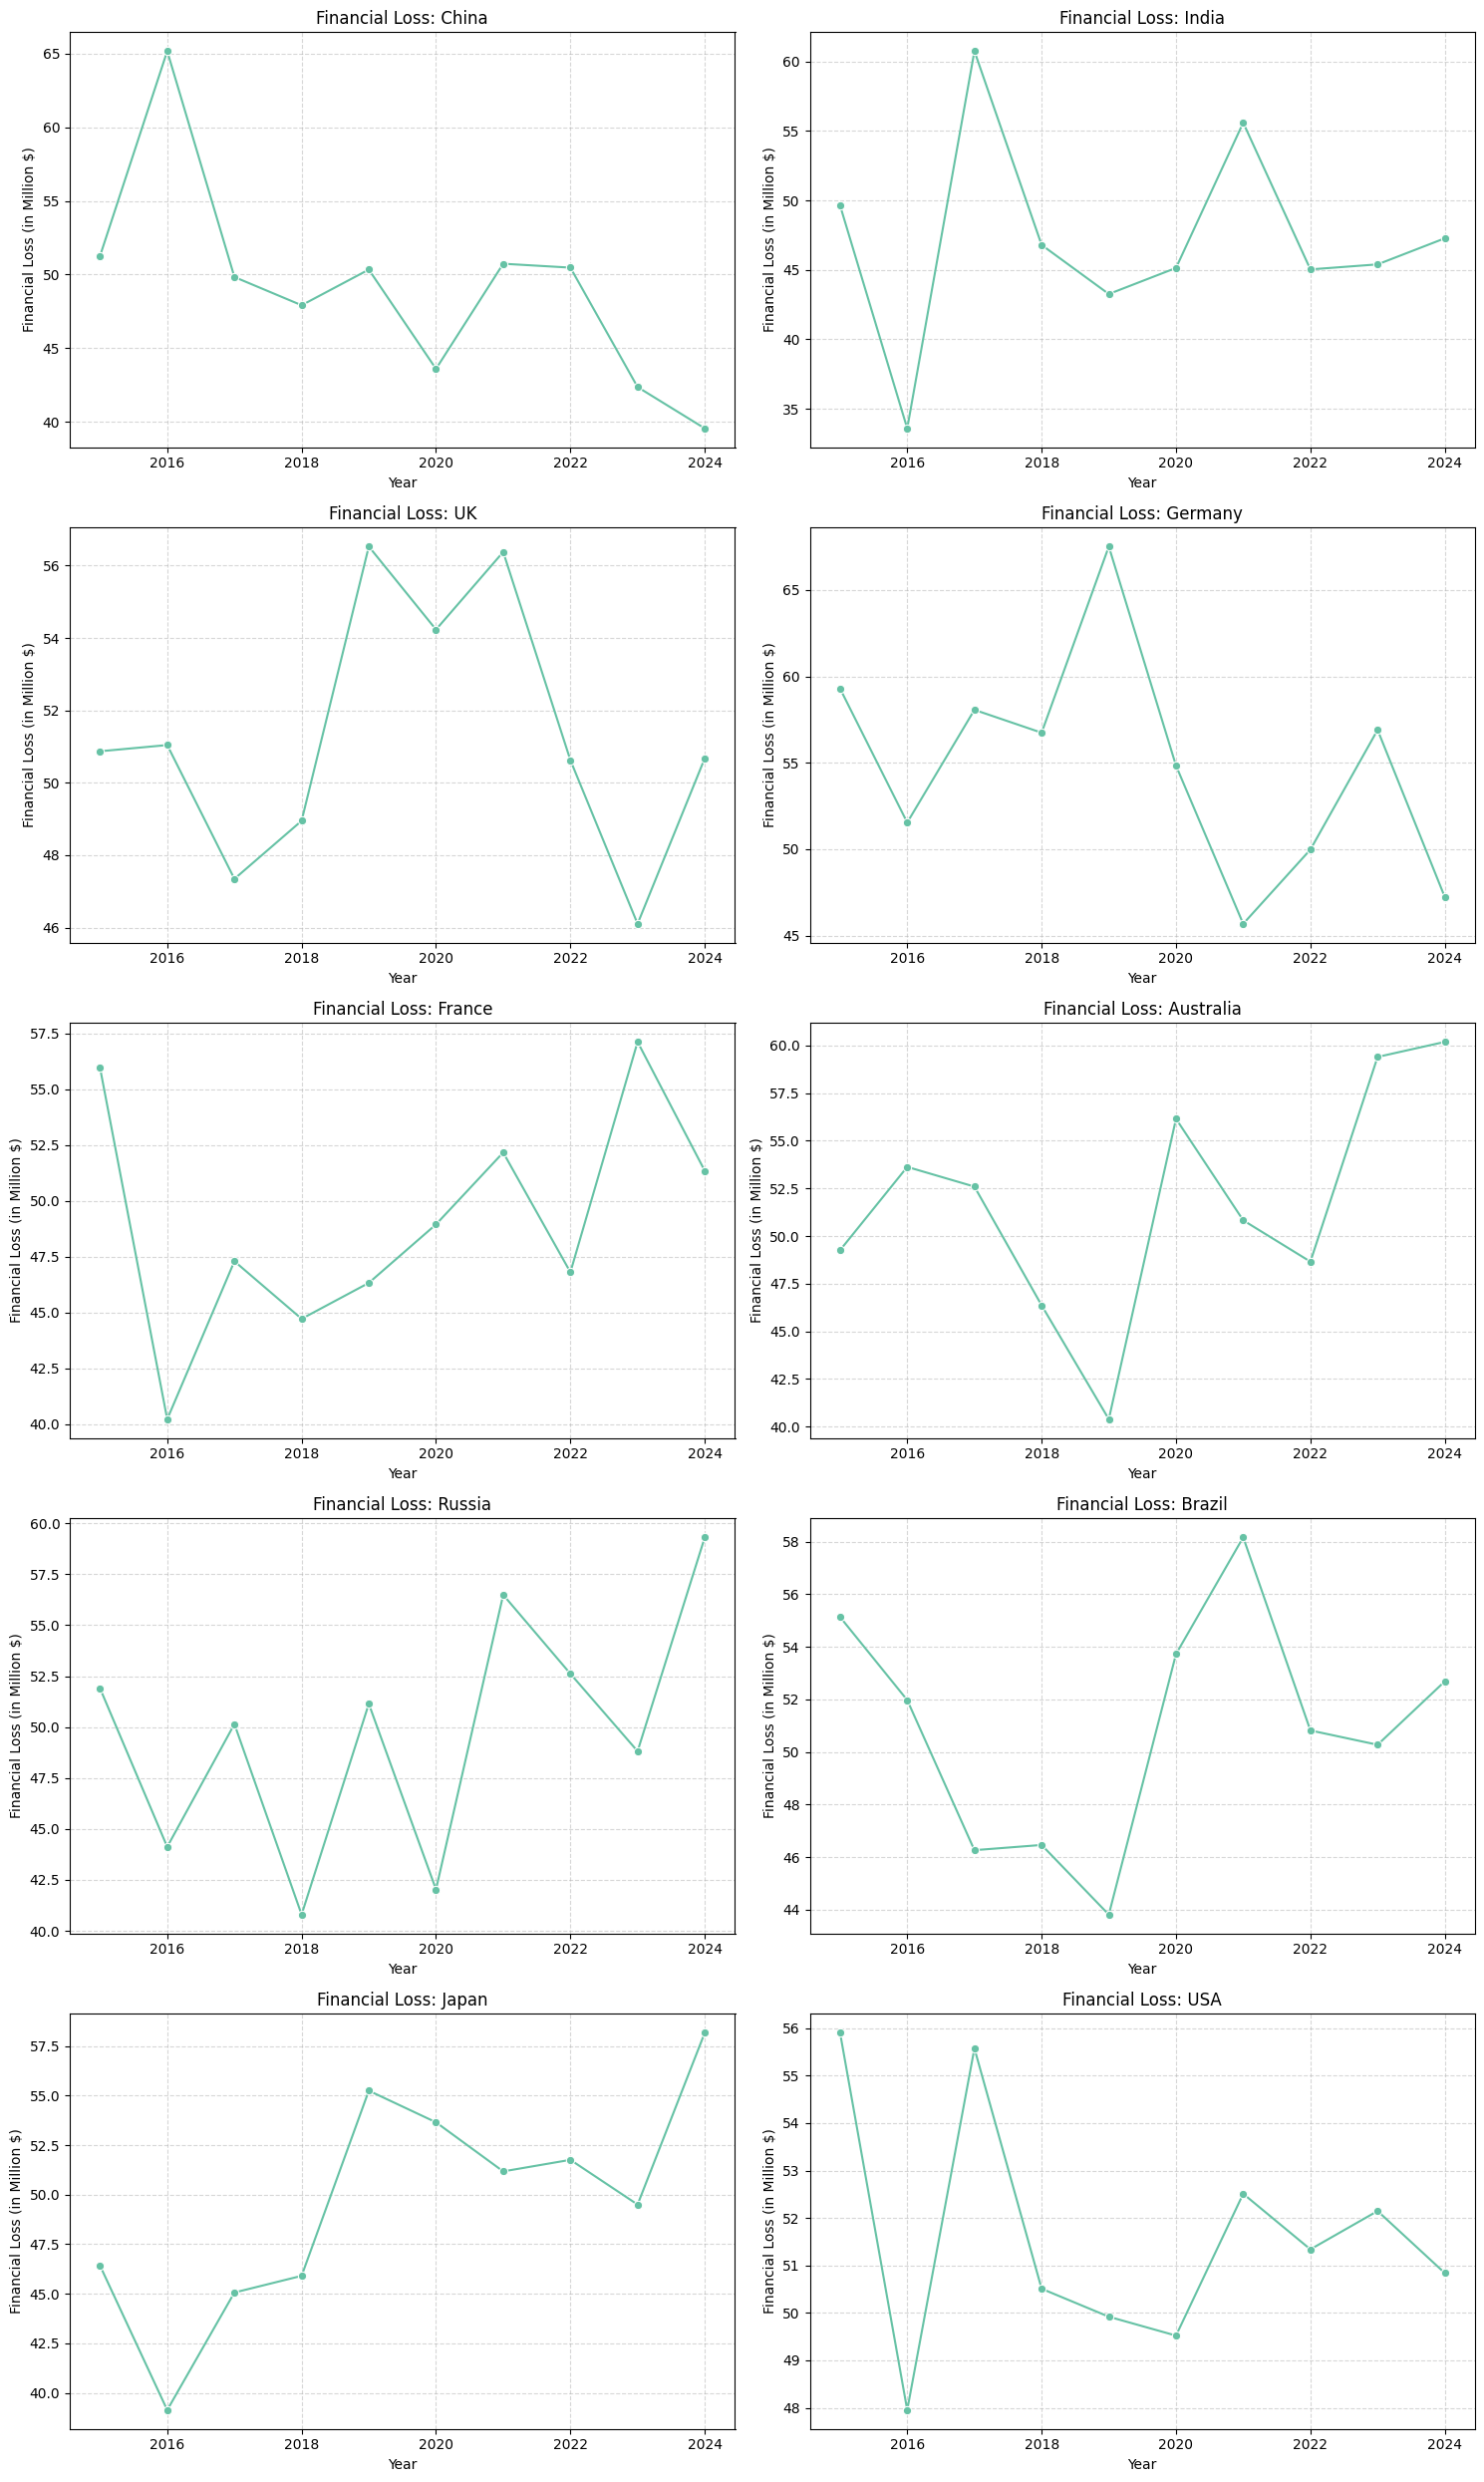

In [9]:
fig, axes = plt.subplots(5, 2, figsize=(15, 25))

axes_flat =  axes.flatten()

# loop for each country separate graph
for i, country in enumerate(countries):
    if i >= len(axes_flat):
        break
    
    country_df = df[df["Country"] == country]
    
    sns.lineplot(
        country_df,
        x="Year",
        y="Financial Loss (in Million $)",
        ax=axes_flat[i],
        marker='o',
        errorbar=None
    )

    axes_flat[i].set_title(f"Financial Loss: {country}", fontsize=12)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5)
    
plt.tight_layout()
plt.show()

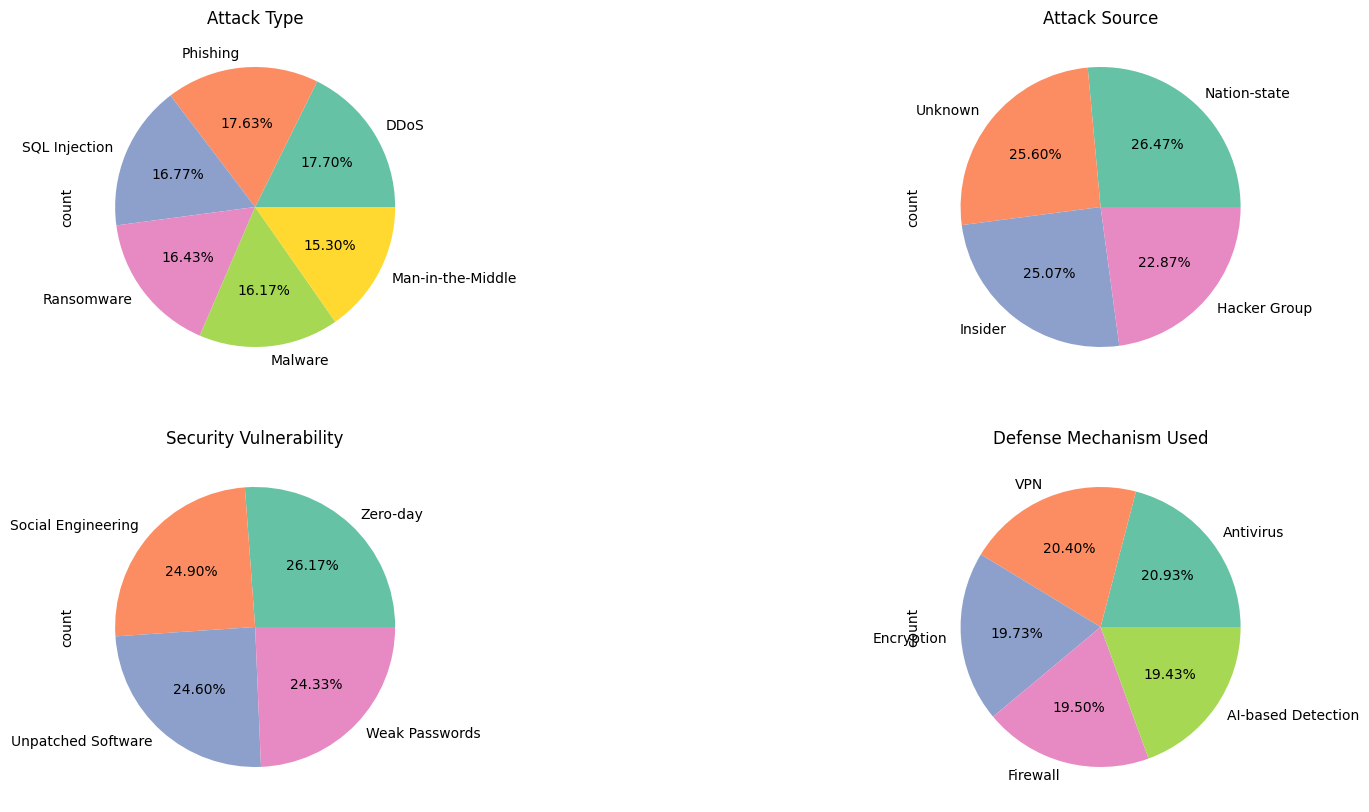

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10)) 

df["Attack Type"].value_counts().plot.pie(autopct="%2.2f%%", ax=ax[0, 0])
ax[0, 0].set_title("Attack Type")

df["Attack Source"].value_counts().plot.pie(autopct="%2.2f%%", ax=ax[0, 1])
ax[0, 1].set_title("Attack Source")

df["Security Vulnerability Type"].value_counts().plot.pie(autopct="%2.2f%%", ax=ax[1, 0])
ax[1, 0].set_title("Security Vulnerability")

df["Defense Mechanism Used"].value_counts().plot.pie(autopct="%2.2f%%", ax=ax[1, 1])
ax[1, 1].set_title("Defense Mechanism Used")
    
plt.show()

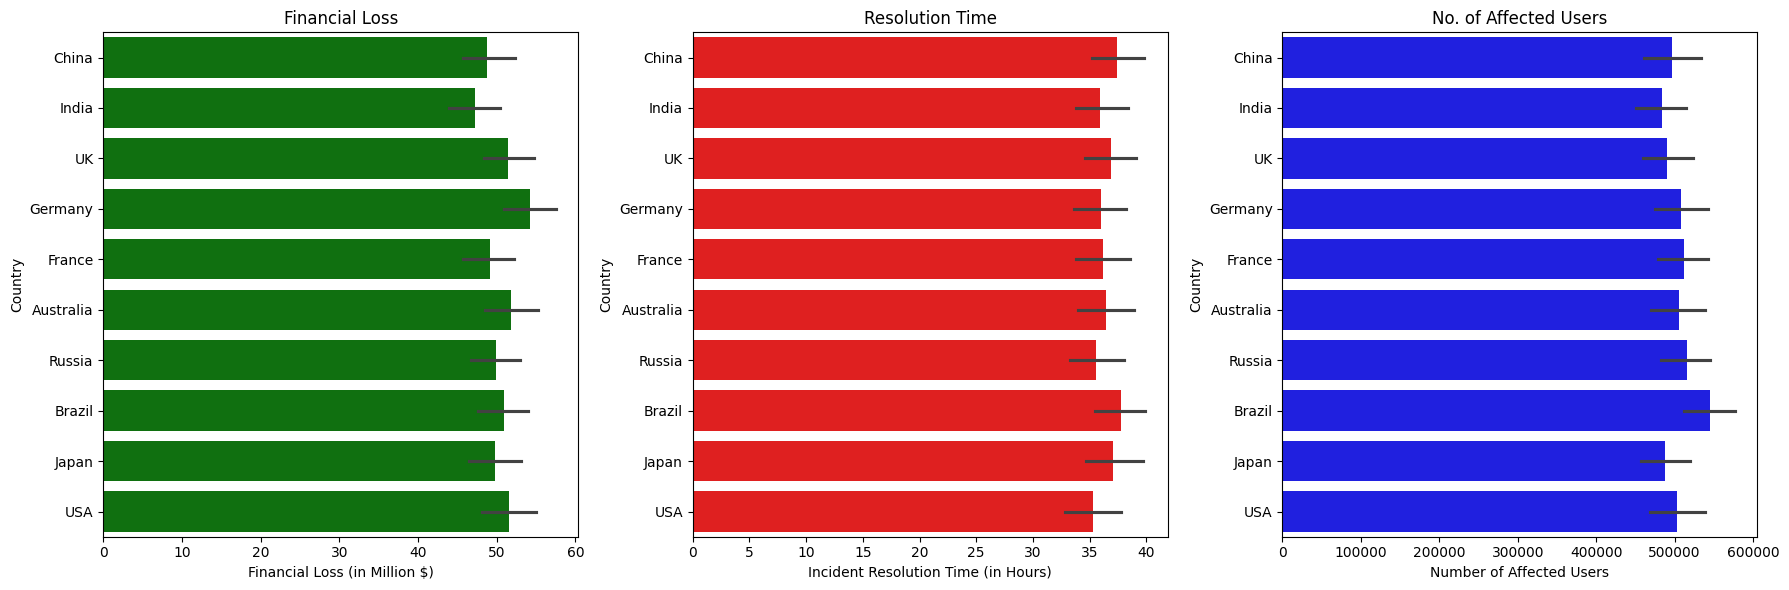

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6)) 

sns.barplot(data=df, x="Financial Loss (in Million $)", y="Country", ax=ax[0], color="green")
ax[0].set_title("Financial Loss")

sns.barplot(data=df, x="Incident Resolution Time (in Hours)", y="Country", ax=ax[1], color="red")
ax[1].set_title("Resolution Time")

sns.barplot(data=df, x="Number of Affected Users", y="Country", ax=ax[2], color="blue")
ax[2].set_title("No. of Affected Users")

plt.tight_layout()
plt.show()

In [14]:
df.describe(include="all")

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
count,3000,3000.000000,3000,3000,3000.000000,3000.000000,3000,3000,3000,3000.000000
unique,10,NaN,6,7,NaN,NaN,4,4,5,NaN
top,UK,NaN,DDoS,IT,NaN,NaN,Nation-state,Zero-day,Antivirus,NaN
freq,321,NaN,531,478,NaN,NaN,794,785,628,NaN
mean,NaN,2019.570333,NaN,NaN,50.492970,504684.136333,NaN,NaN,NaN,36.476000
std,NaN,2.857932,NaN,NaN,28.791415,289944.084972,NaN,NaN,NaN,20.570768
min,NaN,2015.000000,NaN,NaN,0.500000,424.000000,NaN,NaN,NaN,1.000000
25%,NaN,2017.000000,NaN,NaN,25.757500,255805.250000,NaN,NaN,NaN,19.000000
50%,NaN,2020.000000,NaN,NaN,50.795000,504513.000000,NaN,NaN,NaN,37.000000
75%,NaN,2022.000000,NaN,NaN,75.630000,758088.500000,NaN,NaN,NaN,55.000000


In [ ]:
df.show_pos_index()

plot_schema = {
    "line": {df, 0, 1},
    "bar": {df, x="col_1", y="col_2"},
    "pie": {df, x=3, y2},
    "scatter": {df, 4, 1},
    "heatmap": {df, 1, 2,3, 4, 5},
    "hist": {df, 2, 4}
}

qe.fig_show(plot_schema, renders="iframe")

TypeError: unhashable type: 'DataFrame'